# Mid-Term 1

Sina Hatami (S5447389)


In [1]:
import time
import scipy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


In [2]:
def load_dataset(name):
    X, y = [], []
    with open("{}".format(name), 'r') as f:
        for line in f.readlines():
            splitted = line.split(",")
            X.append(splitted[:-1])
            y.append(splitted[-1])
    X, y = np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)
    return X, y

### Prelude

Load the following 7 datasets:

- dataset 1: (X1, y1) with $X1 \in \mathbb{R}^{ 50 \times 10}$ and noise variance $\sigma = 0.1$
- dataset 2: (X2, y2) with $X2 \in \mathbb{R}^{ 500 \times 10}$ and noise variance $\sigma = 0.1$
- dataset 3: (X3, y3) with $X3 \in \mathbb{R}^{ 1000 \times 10}$ and noise variance $\sigma = 0.1$
- dataset 4: (X4, y4) with $X4 \in \mathbb{R}^{ 500 \times 500}$ and noise variance $\sigma = 0.1$
- dataset 5: (X5, y5) with $X5 \in \mathbb{R}^{ 500 \times 5000}$ and noise variance $\sigma = 0.1$
- dataset 6: (X6, y6) with $X6 \in \mathbb{R}^{ 500 \times 10000}$ and noise variance $\sigma = 0.1$
- dataset 7: (X7, y7) with $X7 \in \mathbb{R}^{ 500 \times 1}$ and noise variance $\sigma = 0.3$

i.e. datasets from 1 to 3 have fixed input space dimension $d = 10$ and different number of points, while datasets from 4 to 6 have fixed number of points and different number of dimensions.

In [3]:
# Load dataset 1
(Xtr_1, ytr_1), (Xte_1, yte_1) = load_dataset("./datasets/dataset_1_train"), load_dataset("./datasets/dataset_1_test")

#Load dataset 2
(Xtr_2, ytr_2), (Xte_2, yte_2) = load_dataset("./datasets/dataset_2_train"), load_dataset("./datasets/dataset_2_test")

#Load dataset 3
(Xtr_3, ytr_3), (Xte_3, yte_3) = load_dataset("./datasets/dataset_3_train"), load_dataset("./datasets/dataset_3_test")

#Load dataset 4
(Xtr_4, ytr_4), (Xte_4, yte_4) = load_dataset("./datasets/dataset_4_train"), load_dataset("./datasets/dataset_4_test")

#Load dataset 5
(Xtr_5, ytr_5), (Xte_5, yte_5) = load_dataset("./datasets/dataset_5_train"), load_dataset("./datasets/dataset_5_test")

#Load datset 6
(Xtr_6, ytr_6), (Xte_6, yte_6) = load_dataset("./datasets/dataset_6_train"), load_dataset("./datasets/dataset_6_test")

#Load datset 7
Xtr_7, ytr_7 = load_dataset("./datasets/dataset_7_train")

# SUGGESTION!!! Check the size of each dataset

#Example
print(np.shape(Xtr_1))


(40, 10)


Tips and tricks:
- to estimate the computational time of a certain portion of code use the following
    
    `
    t0 = time.time()
    ... my code ...
    mycode_time = time.time()-t0`

In [4]:
# Example

t0 = time.time()
_ = load_dataset("./datasets/dataset_3_train")
DeltaT = time.time() - t0

print("[--] Dataset 3 loaded in {} seconds".format(DeltaT))

[--] Dataset 3 loaded in 0.004396200180053711 seconds


### Activity 1 

Compare the behavior of K-NN and RLS on the datasets according to the following tasks:
- Task 1.1: Compare training, validation, test errors and training and test time of the two methods on datasets 1, 2, 3
- Task 1.2: Compare training, validation, test errors and training and test time of the two methods on datasets 4, 5, 6 




In [5]:
Ks = list(range(1, 100, 10))
lams = np.logspace(-9, 2, 10)
KF = 5

# TASK 1.1

# cross validation of KNN for dataset 1
knn_cv1 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_1)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv1.fit(Xtr_1, ytr_1)

# cross validation of RLS for dataset 1
rls_cv1 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv1.fit(Xtr_1, ytr_1)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn1 = KNeighborsRegressor(n_neighbors=knn_cv1.best_params_['n_neighbors'])
knn1.fit(Xtr_1, ytr_1)
knn1_train_time = time.time() - t0

t0 = time.time()
knn1_test_err = mean_squared_error(yte_1, knn1.predict(Xte_1))
knn1_test_time = time.time() - t0
print(f"Dataset 1 [K-NN] Train Time: {knn1_train_time:.4f}s, Test Time: {knn1_test_time:.4f}s, Test MSE: {knn1_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls1 = Ridge(alpha=rls_cv1.best_params_['alpha'])
rls1.fit(Xtr_1, ytr_1)
rls1_train_time = time.time() - t0

t0 = time.time()
rls1_test_err = mean_squared_error(yte_1, rls1.predict(Xte_1))
rls1_test_time = time.time() - t0
print(f"Dataset 1 [RLS] Train Time: {rls1_train_time:.4f}s, Test Time: {rls1_test_time:.4f}s, Test MSE: {rls1_test_err:.4f}")

# cross validation of KNN for dataset 2
knn_cv2 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_2)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv2.fit(Xtr_2, ytr_2)

# cross validation of RLS for dataset 2
rls_cv2 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv2.fit(Xtr_2, ytr_2)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn2 = KNeighborsRegressor(n_neighbors=knn_cv2.best_params_['n_neighbors'])
knn2.fit(Xtr_2, ytr_2)
knn2_train_time = time.time() - t0

t0 = time.time()
knn2_test_err = mean_squared_error(yte_2, knn2.predict(Xte_2))
knn2_test_time = time.time() - t0
print(f"Dataset 2 [K-NN] Train Time: {knn2_train_time:.4f}s, Test Time: {knn2_test_time:.4f}s, Test MSE: {knn2_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls2 = Ridge(alpha=rls_cv2.best_params_['alpha'])
rls2.fit(Xtr_2, ytr_2)
rls2_train_time = time.time() - t0

t0 = time.time()
rls2_test_err = mean_squared_error(yte_2, rls2.predict(Xte_2))
rls2_test_time = time.time() - t0
print(f"Dataset 2 [RLS] Train Time: {rls2_train_time:.4f}s, Test Time: {rls2_test_time:.4f}s, Test MSE: {rls2_test_err:.4f}")

# cross validation of KNN for dataset 3
knn_cv3 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_3)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv3.fit(Xtr_3, ytr_3)

# cross validation of RLS for dataset 3
rls_cv3 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv3.fit(Xtr_3, ytr_3)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn3 = KNeighborsRegressor(n_neighbors=knn_cv3.best_params_['n_neighbors'])
knn3.fit(Xtr_3, ytr_3)
knn3_train_time = time.time() - t0

t0 = time.time()
knn3_test_err = mean_squared_error(yte_3, knn3.predict(Xte_3))
knn3_test_time = time.time() - t0
print(f"Dataset 3 [K-NN] Train Time: {knn3_train_time:.4f}s, Test Time: {knn3_test_time:.4f}s, Test MSE: {knn3_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls3 = Ridge(alpha=rls_cv3.best_params_['alpha'])
rls3.fit(Xtr_3, ytr_3)
rls3_train_time = time.time() - t0

t0 = time.time()
rls3_test_err = mean_squared_error(yte_3, rls3.predict(Xte_3))
rls3_test_time = time.time() - t0
print(f"Dataset 3 [RLS] Train Time: {rls3_train_time:.4f}s, Test Time: {rls3_test_time:.4f}s, Test MSE: {rls3_test_err:.4f}")

# TASK 1.2

# cross validation of KNN for dataset 4
knn_cv4 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_4)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv4.fit(Xtr_4, ytr_4)

# cross validation of RLS for dataset 4
rls_cv4 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv4.fit(Xtr_4, ytr_4)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn4 = KNeighborsRegressor(n_neighbors=knn_cv4.best_params_['n_neighbors'])
knn4.fit(Xtr_4, ytr_4)
knn4_train_time = time.time() - t0

t0 = time.time()
knn4_test_err = mean_squared_error(yte_4, knn4.predict(Xte_4))
knn4_test_time = time.time() - t0
print(f"Dataset 4 [K-NN] Train Time: {knn4_train_time:.4f}s, Test Time: {knn4_test_time:.4f}s, Test MSE: {knn4_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls4 = Ridge(alpha=rls_cv4.best_params_['alpha'])
rls4.fit(Xtr_4, ytr_4)
rls4_train_time = time.time() - t0

t0 = time.time()
rls4_test_err = mean_squared_error(yte_4, rls4.predict(Xte_4))
rls4_test_time = time.time() - t0
print(f"Dataset 4 [RLS] Train Time: {rls4_train_time:.4f}s, Test Time: {rls4_test_time:.4f}s, Test MSE: {rls4_test_err:.4f}")

# cross validation of KNN for dataset 5
knn_cv5 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_5)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv5.fit(Xtr_5, ytr_5)

# cross validation of RLS for dataset 5
rls_cv5 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv5.fit(Xtr_5, ytr_5)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn5 = KNeighborsRegressor(n_neighbors=knn_cv5.best_params_['n_neighbors'])
knn5.fit(Xtr_5, ytr_5)
knn5_train_time = time.time() - t0

t0 = time.time()
knn5_test_err = mean_squared_error(yte_5, knn5.predict(Xte_5))
knn5_test_time = time.time() - t0
print(f"Dataset 5 [K-NN] Train Time: {knn5_train_time:.4f}s, Test Time: {knn5_test_time:.4f}s, Test MSE: {knn5_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls5 = Ridge(alpha=rls_cv5.best_params_['alpha'])
rls5.fit(Xtr_5, ytr_5)
rls5_train_time = time.time() - t0

t0 = time.time()
rls5_test_err = mean_squared_error(yte_5, rls5.predict(Xte_5))
rls5_test_time = time.time() - t0
print(f"Dataset 5 [RLS] Train Time: {rls5_train_time:.4f}s, Test Time: {rls5_test_time:.4f}s, Test MSE: {rls5_test_err:.4f}")

# cross validation of KNN for dataset 6
knn_cv6 = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [k for k in Ks if k <= len(Xtr_6)]}, cv=KF, scoring='neg_mean_squared_error')
knn_cv6.fit(Xtr_6, ytr_6)

# cross validation of RLS for dataset 6
rls_cv6 = GridSearchCV(Ridge(), {'alpha': lams}, cv=KF, scoring='neg_mean_squared_error')
rls_cv6.fit(Xtr_6, ytr_6)

# train KNN with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
knn6 = KNeighborsRegressor(n_neighbors=knn_cv6.best_params_['n_neighbors'])
knn6.fit(Xtr_6, ytr_6)
knn6_train_time = time.time() - t0

t0 = time.time()
knn6_test_err = mean_squared_error(yte_6, knn6.predict(Xte_6))
knn6_test_time = time.time() - t0
print(f"Dataset 6 [K-NN] Train Time: {knn6_train_time:.4f}s, Test Time: {knn6_test_time:.4f}s, Test MSE: {knn6_test_err:.4f}")

# train RLS with parameter obtained by KFold-Cross Validation and estimate computational time

t0 = time.time()
rls6 = Ridge(alpha=rls_cv6.best_params_['alpha'])
rls6.fit(Xtr_6, ytr_6)
rls6_train_time = time.time() - t0

t0 = time.time()
rls6_test_err = mean_squared_error(yte_6, rls6.predict(Xte_6))
rls6_test_time = time.time() - t0
print(f"Dataset 6 [RLS] Train Time: {rls6_train_time:.4f}s, Test Time: {rls6_test_time:.4f}s, Test MSE: {rls6_test_err:.4f}")



# Tips: to compare the methods, you should 
# - plot training and validation errors for the different hypeparameter values considered in the cross-validation procedure
# - print in output the training, validation and test errors corresponding to the final model


Dataset 1 [K-NN] Train Time: 0.0004s, Test Time: 0.0012s, Test MSE: 8.3879
Dataset 1 [RLS] Train Time: 0.0012s, Test Time: 0.0007s, Test MSE: 10.5374


Dataset 2 [K-NN] Train Time: 0.0009s, Test Time: 0.0015s, Test MSE: 10.4806
Dataset 2 [RLS] Train Time: 0.0009s, Test Time: 0.0004s, Test MSE: 19.2666


Dataset 3 [K-NN] Train Time: 0.0009s, Test Time: 0.0038s, Test MSE: 10.3944
Dataset 3 [RLS] Train Time: 0.0014s, Test Time: 0.0009s, Test MSE: 7.5379


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.9423556924257355e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3020609035407915e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.9423556924257355e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


...

/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.0510674542405525e-10.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.610503338639774e-10.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4658540098698722e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4104195972540765e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.316845204575202e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4430475420444964e-08.
  dual_coef = linalg.solve(K,

/home/sina/dev/projects/ml/venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.953621087125157e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Dataset 6 [K-NN] Train Time: 0.0034s, Test Time: 0.2119s, Test MSE: 11482.5000
Dataset 6 [RLS] Train Time: 0.0685s, Test Time: 0.0033s, Test MSE: 11805.0986


What can you observe? **Describe here your observations:**

- **Curse of Dimensionality:** As the number of dimensions increases (Datasets 4, 5, 6), K-NN's performance severely degrades. This is because distance metrics become less meaningful in high-dimensional spaces (the points become uniformly distant from each other). RLS (Ridge Regression) is much more robust to high dimensionality.
- **Computational Complexity:** K-NN has zero training time but extremely high inference/test time, especially for large $N$ (Dataset 3). RLS takes time to train (inverting matrices) but inference is essentially instantaneous.
- **Sample Size:** Increasing the sample size (Datasets 1, 2, 3) generally improves the generalization capabilities of both models, lowering the test error.


### Acitivity 2

Find your optimal solution for the dataset 7, we will evaluate the goodness of your model on the test set

Text(0, 0.5, 'y')

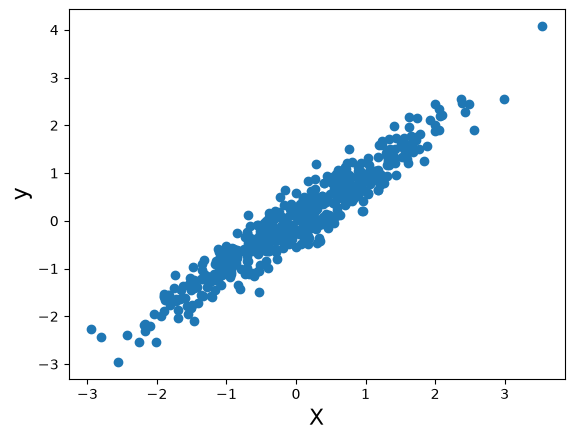

In [6]:
fig, ax = plt.subplots()
ax.plot(Xtr_7, ytr_7, 'o')
ax.set_xlabel("X", fontsize=16)
ax.set_ylabel("y", fontsize=16)

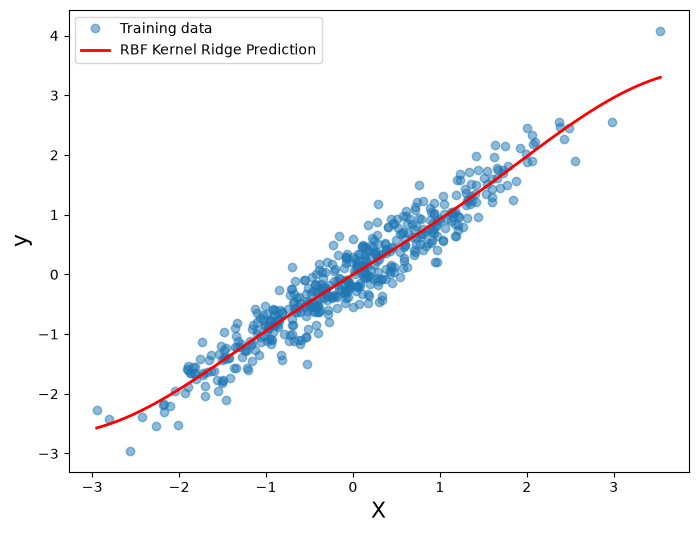

In [7]:
from sklearn.kernel_ridge import KernelRidge

# Dataset 7 is 1D. We use an RBF Kernel Ridge Regressor to capture the non-linearities.
krr = KernelRidge(kernel='rbf', alpha=0.1, gamma=0.1)
krr.fit(Xtr_7, ytr_7)

X_plot = np.linspace(Xtr_7.min(), Xtr_7.max(), 100)[:, None]
y_plot = krr.predict(X_plot)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(Xtr_7, ytr_7, 'o', label='Training data', alpha=0.5)
ax.plot(X_plot, y_plot, '-', color='red', label='RBF Kernel Ridge Prediction', linewidth=2)
ax.set_xlabel("X", fontsize=16)
ax.set_ylabel("y", fontsize=16)
ax.legend()
plt.show()
